### Import

In [5]:
# Cell 1 : Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliothèques importées")

Matplotlib is building the font cache; this may take a moment.


✅ Bibliothèques importées


### Charger les données

In [10]:
# Cell 2 : Charger les données
from pathlib import Path

# Détecter automatiquement le chemin
PROJECT_ROOT = Path.cwd().parent.parent  # Remonte à la racine du projet
csv_path = PROJECT_ROOT / "data_engineering" / "transformations" / "output" / "openalex_transformed.csv"

print(f"📁 Chemin: {csv_path}")
print(f"✅ Existe: {csv_path.exists()}")

df = pd.read_csv(csv_path)

print(f"📊 Dataset : {len(df)} lignes, {len(df.columns)} colonnes")
print(f"\n📋 Colonnes :")
for col in df.columns:
    print(f"   - {col}")

df.head()

📁 Chemin: c:\Users\hamouchizineb\morocco-data-intelligence-platform\data_engineering\transformations\output\openalex_transformed.csv
✅ Existe: True
📊 Dataset : 100 lignes, 12 colonnes

📋 Colonnes :
   - openalex_id
   - title
   - publication_year
   - doi
   - citation_count
   - publication_type
   - language
   - journal
   - is_open_access
   - oa_status
   - title_length
   - id


,openalex_id,title,publication_year,doi,citation_count,publication_type,language,journal,is_open_access,oa_status,title_length,id
0,https://openalex.org/W4395028739,Impact of ChatGPT on Academic Writing at Moroc...,2024,https://doi.org/10.24093/awej/chatgpt.1,8,article,en,Arab World English Journal,True,diamond,62,d5469c622ab1a8170276c82c89079f4e
1,https://openalex.org/W4392376877,Multidimensional determinants of academic perf...,2024,https://doi.org/10.3926/jotse.2404,11,article,en,Journal of Technology and Science Education,True,gold,116,34a0f15973c2026bc927b022f92c6772
2,https://openalex.org/W4399972612,AI-driven empowerment of international higher ...,2024,https://doi.org/10.21107/sml.v7i1.21911,9,article,en,SIMULACRA JURNAL SOSIOLOGI,True,diamond,123,696d027ecaa34d0699903310e07aa358
3,https://openalex.org/W4393285482,The Transition of the Moroccan University to a...,2024,https://doi.org/10.1007/978-3-031-54664-8_37,3,conference-paper,en,Lecture notes in networks and systems,False,closed,94,061adeddb44b83a597eb8340d7f430dd
4,https://openalex.org/W4396530411,The relationship between L2 grit and vocabular...,2024,https://doi.org/10.1016/j.system.2024.103316,7,article,en,System,False,closed,100,3acb73a59a6b80a436fbdfeef2a8f91a


### Statistiques descriptives

In [11]:
# Cell 3 : Statistiques descriptives
print("📊 Statistiques descriptives :")
df.describe()

📊 Statistiques descriptives :


,publication_year,citation_count,title_length
count,100.0,100.000000,100.0000
mean,2024.0,12.330000,116.4900
std,0.0,28.935685,33.8268
min,2024.0,1.000000,43.0000
25%,2024.0,1.000000,96.7500
50%,2024.0,3.000000,114.0000
75%,2024.0,10.250000,143.0000
max,2024.0,259.000000,199.0000


### Valeurs manquantes

In [12]:
# Cell 4 : Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Manquant': missing,
    'Pourcentage': missing_pct
}).sort_values('Pourcentage', ascending=False)

print("🔍 Valeurs manquantes :")
print(missing_df[missing_df['Manquant'] > 0])

🔍 Valeurs manquantes :
         Manquant  Pourcentage
journal         4          4.0


### Distribution des publications par année

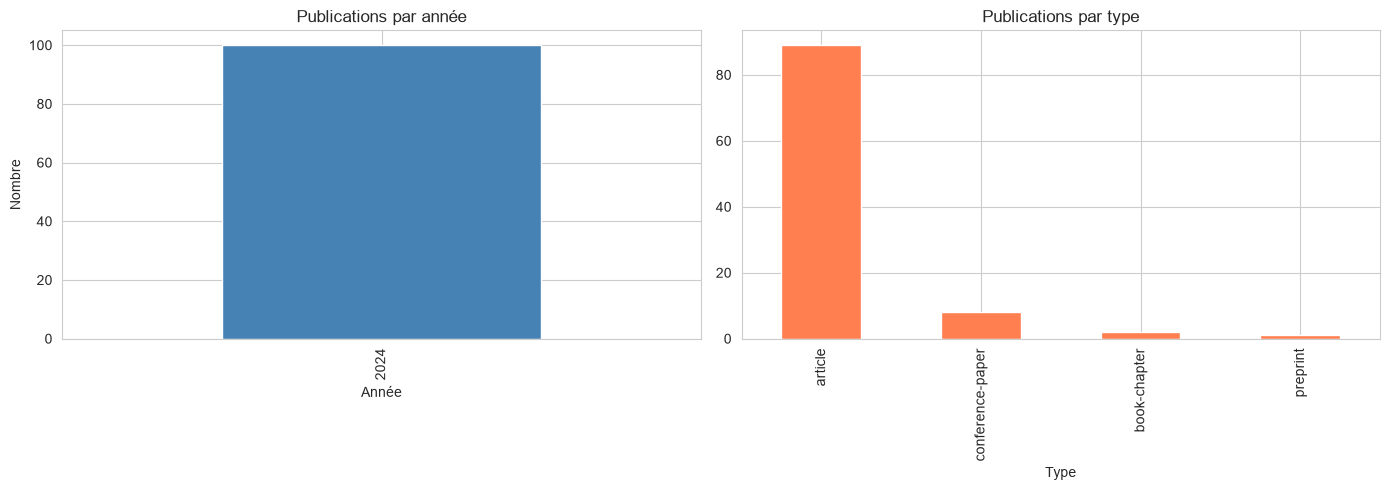

In [13]:
# Cell 5 : Distribution des publications par année
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par année
df['publication_year'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Publications par année')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre')

# Par type
df['publication_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Publications par type')
axes[1].set_xlabel('Type')

plt.tight_layout()
plt.show()

### Distribution des citations

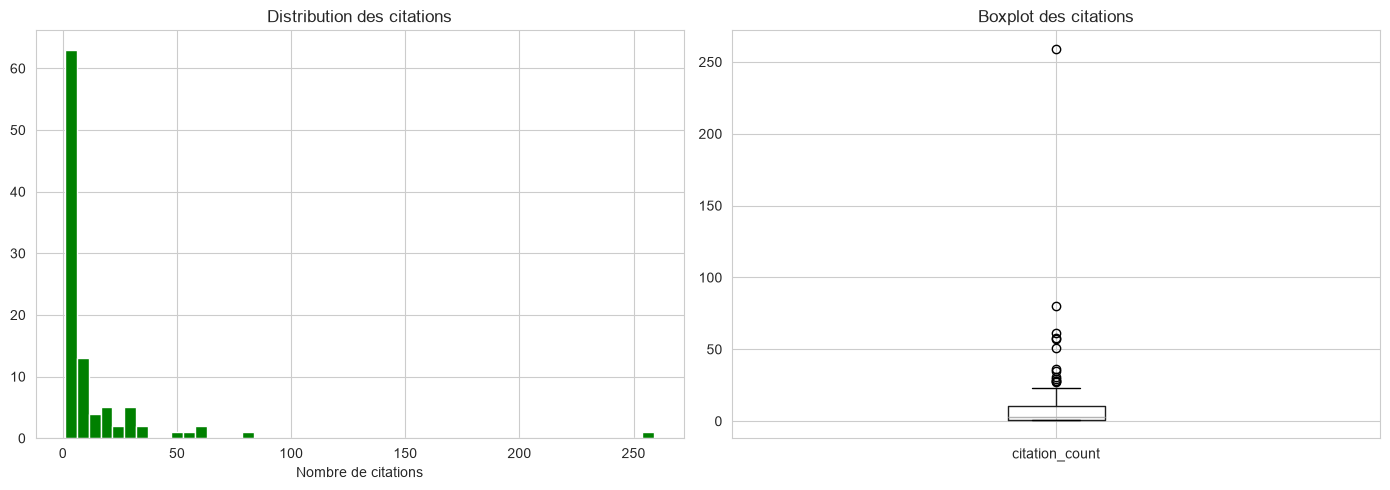

📊 Citations :
   - Moyenne : 12.33
   - Médiane : 3.00
   - Max : 259


In [14]:
# Cell 6 : Distribution des citations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des citations
df['citation_count'].hist(bins=50, ax=axes[0], color='green')
axes[0].set_title('Distribution des citations')
axes[0].set_xlabel('Nombre de citations')

# Boxplot
df.boxplot(column='citation_count', ax=axes[1])
axes[1].set_title('Boxplot des citations')

plt.tight_layout()
plt.show()

print(f"📊 Citations :")
print(f"   - Moyenne : {df['citation_count'].mean():.2f}")
print(f"   - Médiane : {df['citation_count'].median():.2f}")
print(f"   - Max : {df['citation_count'].max()}")

### Top 10 journaux

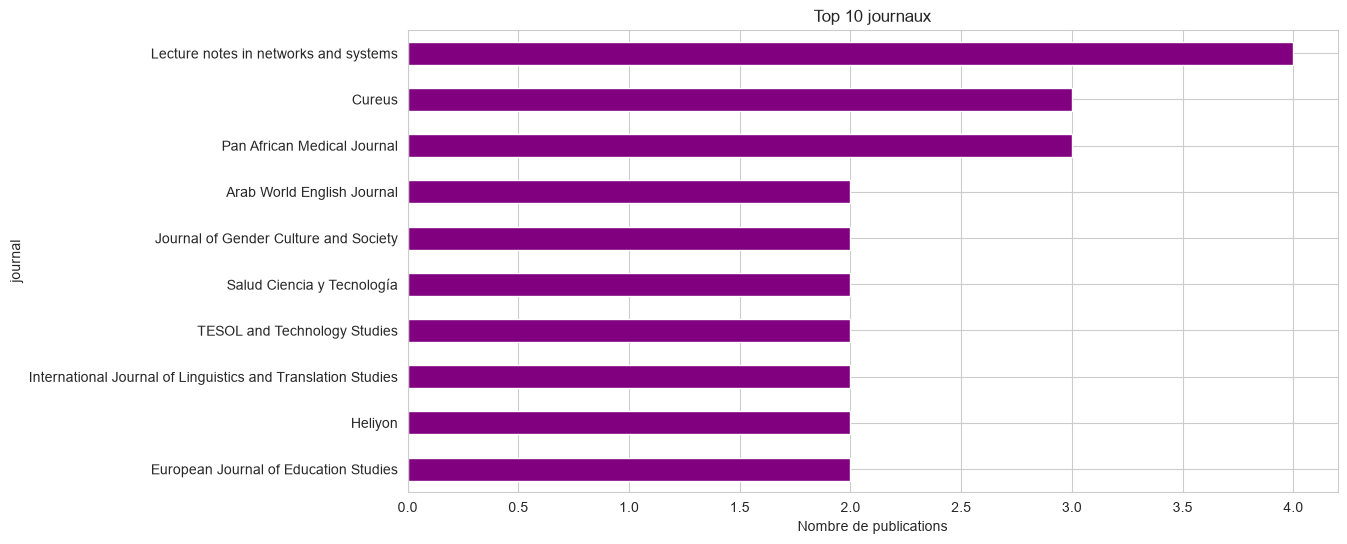

In [15]:
# Cell 7 : Top 10 journaux
top_journals = df['journal'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_journals.plot(kind='barh', color='purple')
plt.title('Top 10 journaux')
plt.xlabel('Nombre de publications')
plt.gca().invert_yaxis()
plt.show()

### Top 10 publications citées

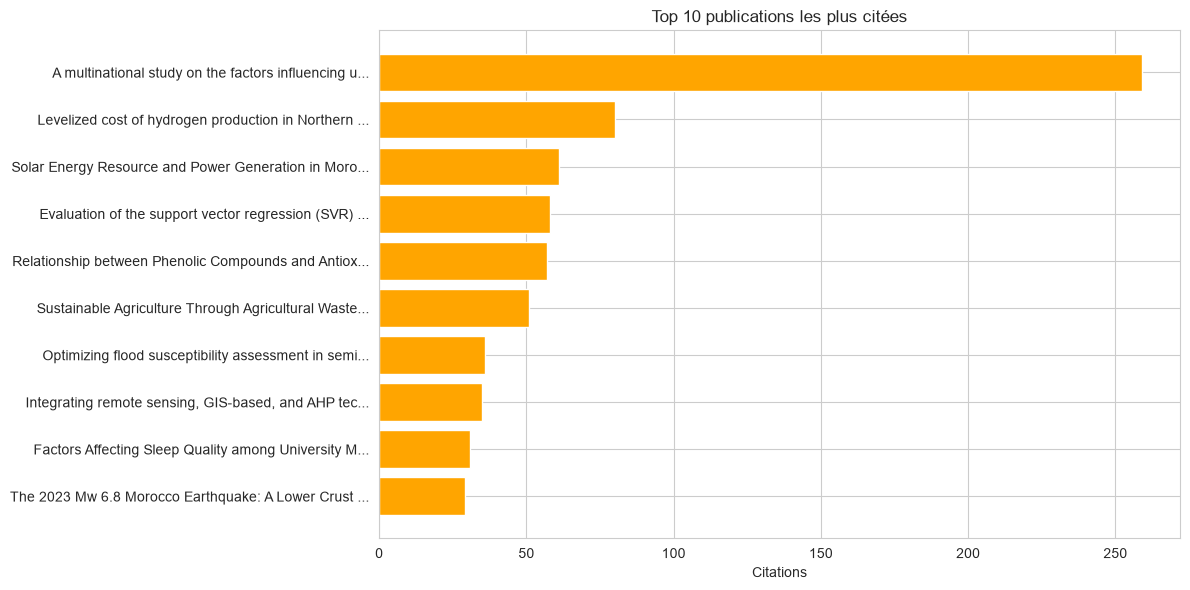

In [16]:
# Cell 8 : Top 10 publications citées
top_cited = df.nlargest(10, 'citation_count')[['title', 'citation_count', 'publication_year']]

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_cited)), top_cited['citation_count'], color='orange')
plt.yticks(range(len(top_cited)), [t[:50] + '...' for t in top_cited['title']])
plt.xlabel('Citations')
plt.title('Top 10 publications les plus citées')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Analyse Open Access

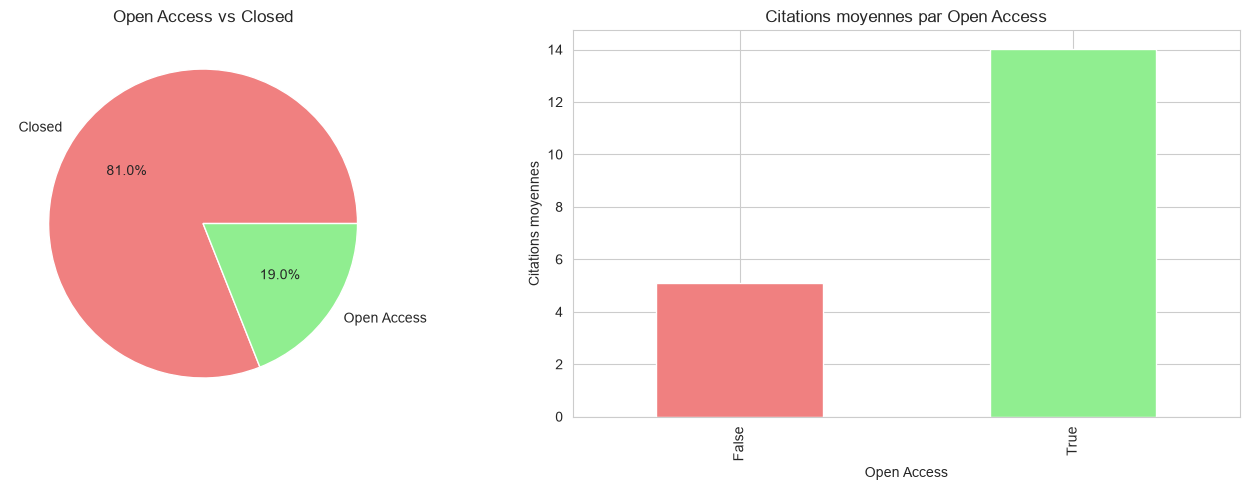

In [17]:
# Cell 9 : Analyse Open Access
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
df['is_open_access'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    labels=['Closed', 'Open Access'], colors=['lightcoral', 'lightgreen']
)
axes[0].set_title('Open Access vs Closed')
axes[0].set_ylabel('')

# Citations par Open Access
df.groupby('is_open_access')['citation_count'].mean().plot(
    kind='bar', ax=axes[1], color=['lightcoral', 'lightgreen']
)
axes[1].set_title('Citations moyennes par Open Access')
axes[1].set_xlabel('Open Access')
axes[1].set_ylabel('Citations moyennes')

plt.tight_layout()
plt.show()